In [1]:
import pandas as pd
import networkx as nx
import matplotlib as plt
import numpy as np
import pprint
from itertools import combinations

# Read data_scopus.csv
data = pd.read_csv("data/data_scopus.csv")
G = nx.Graph()

In [2]:
nodes = []

# Nodes: authors
for row in data.iterrows():
    cell = row[1]["Authors with affiliations"]
    authorIDs = row[1]["Author(s) ID"]
    
    # Skip NaN or non-string cells
    if not isinstance(cell, str):
        continue
    # Split semicolons
    entries = cell.rstrip(";").split(";")
    idEntries = authorIDs.rstrip(";").split(";")

    for entry in range(len(entries)):
        # Split into: [lastname, firstname, affiliation...]
        parts = entries[entry].split(",", 2)

        if len(parts) != 3:
            continue    # malformed entry

        authorID = idEntries[entry]
        name = ",".join(parts[:2])      # Last name, First initial
        affiliation = parts[2]          # Affiliation
        # Append to nodes (ID, (name, affiliation))
        nodes.append((authorID, {"Name": name, "Affiliation": affiliation}))

G.add_nodes_from(nodes)

In [3]:
# Edges: Shared publications
edges = []
for row in data.iterrows():
    if ";" in row[1]["Author(s) ID"]:
        authors = row[1]["Author(s) ID"].rstrip(";").split(";")
        for a1,a2 in combinations(authors,2):
            edges.append((a1,a2))
    else:
        continue

G.add_edges_from(edges)

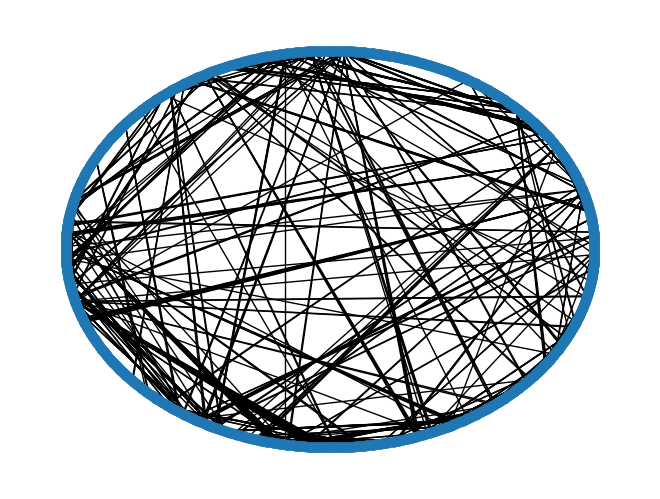

In [4]:
pos = nx.drawing.circular_layout(G)
nx.draw(G, pos=pos, node_size=40)


In [5]:
from networkx.readwrite import json_graph
import json

with open("AuthorNetwork.json", "w") as f:
    json.dump(json_graph.node_link_data(G), f)

E:\python\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [10]:
nodes

[('57202536919',
  {'Name': 'Zhang, Y.',
   'Affiliation': ' Department of Civil and Environmental Engineering, University of Alberta, Edmonton, AB  T6G 1H9, Canada'}),
 ('53984550800',
  {'Name': ' Liu, H.',
   'Affiliation': ' Department of Civil and Construction Engineering, Western Michigan University, Kalamazoo, MI  49008-5316, United States'}),
 ('57215426514',
  {'Name': ' Kang, S.-C.',
   'Affiliation': ' Department of Civil and Environmental Engineering, University of Alberta, Edmonton, AB  T6G 1H9, Canada'}),
 ('6603541102',
  {'Name': ' Al-Hussein, M.',
   'Affiliation': ' Department of Civil and Environmental Engineering, University of Alberta, Edmonton, AB  T6G 1H9, Canada'}),
 ('23398572100',
  {'Name': 'Rapp, A.',
   'Affiliation': ' Computer Science Department, University of Torino, C.so Svizzera, 185, Torino, 10149, Italy'}),
 ('57191836654',
  {'Name': ' Tirabeni, L.',
   'Affiliation': ' Department of Cultures, Politics and Society, University of Torino, Torino, Ital

In [11]:
edges

[('57202536919', '53984550800'),
 ('57202536919', '57215426514'),
 ('57202536919', '6603541102'),
 ('53984550800', '57215426514'),
 ('53984550800', '6603541102'),
 ('57215426514', '6603541102'),
 ('23398572100', '57191836654'),
 ('57205293410', '56421700900'),
 ('57205293410', '24831175200'),
 ('57205293410', '36195159400'),
 ('57205293410', '6507346536'),
 ('57205293410', '6602981892'),
 ('56421700900', '24831175200'),
 ('56421700900', '36195159400'),
 ('56421700900', '6507346536'),
 ('56421700900', '6602981892'),
 ('24831175200', '36195159400'),
 ('24831175200', '6507346536'),
 ('24831175200', '6602981892'),
 ('36195159400', '6507346536'),
 ('36195159400', '6602981892'),
 ('6507346536', '6602981892'),
 ('57201502480', '57171240600'),
 ('57201502480', '35373203100'),
 ('57201502480', '25925695500'),
 ('57201502480', '57200282319'),
 ('57171240600', '35373203100'),
 ('57171240600', '25925695500'),
 ('57171240600', '57200282319'),
 ('35373203100', '25925695500'),
 ('35373203100', '57200